# BatchNorm: Forward Pass, Manual Backward, and the Covariate Shift Problem

> *"Batch Normalization accelerates Deep Network Training by Reducing Internal Covariate Shift"*
> — Ioffe & Szegedy, 2015

This notebook builds BatchNorm entirely from scratch — no `nn.BatchNorm1d`.
We derive the backward pass by hand, verify it against PyTorch autograd,
and run experiments to show *why* it matters for deep network training.

## What problem does BatchNorm solve?

Consider a deep network. As weights update in layer 1, the distribution of inputs
to layer 2 shifts — the deeper layers have to continually re-adapt to a moving target.
This is **internal covariate shift**, and it forces us to use:
- small learning rates (to avoid oscillation)
- careful initialization (Xavier/He)
- saturating activations cautiously (tanh/sigmoid vanish with large inputs)

BatchNorm fixes this by re-centering and re-scaling the inputs to each layer
at every forward pass, using batch statistics.


In [1]:
import sys; sys.path.insert(0, '../src')
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from norms import BatchNorm1dManual, check_gradients
from visualize import (plot_activation_distributions, plot_gradient_flow,
                       plot_training_curves, plot_covariate_shift,
                       plot_normalization_geometry, plot_running_stats,
                       plot_gradient_check)
from train import make_dataset, compare_norms, NormMLP


## 1. The Forward Pass

Given input $X \in \mathbb{R}^{N \times D}$:

$$\mu_j = \frac{1}{N} \sum_{i=1}^{N} x_{ij} \quad \text{(per-feature mean)}$$

$$\sigma^2_j = \frac{1}{N} \sum_{i=1}^{N} (x_{ij} - \mu_j)^2 \quad \text{(per-feature variance, biased)}$$

$$\hat{x}_{ij} = \frac{x_{ij} - \mu_j}{\sqrt{\sigma^2_j + \epsilon}} \quad \text{(normalize)}$$

$$y_{ij} = \gamma_j \hat{x}_{ij} + \beta_j \quad \text{(affine transform, learnable)}$$

Key insight: $\gamma$ and $\beta$ give the network the ability to **undo** the normalization
if needed. Without them, every layer would be forced into unit-normal distribution — but
the network might have learned that a different scale is useful for the activation function.


In [2]:
# Forward pass walkthrough — step by step, no abstraction
torch.manual_seed(0)
N, D = 8, 4   # tiny batch for illustration
eps  = 1e-5

x = torch.randn(N, D) * 3 + 2   # intentionally non-zero mean, non-unit std
print("Input x (before BN):")
print(f"  shape: {x.shape}")
print(f"  mean per feature: {x.mean(0).tolist()}")
print(f"  std  per feature: {x.std(0).tolist()}")

# Step 1: per-feature statistics
mu  = x.mean(dim=0)                       # (D,)
var = x.var(dim=0, unbiased=False)        # (D,)

# Step 2: normalize
x_hat = (x - mu) / torch.sqrt(var + eps) # (N, D)
print("\nAfter normalization (x_hat):")
print(f"  mean per feature: {x_hat.mean(0).tolist()}")
print(f"  std  per feature: {x_hat.std(0).tolist()}")

# Step 3: affine
gamma = torch.ones(D)
beta  = torch.zeros(D)
out   = gamma * x_hat + beta
print("\nOutput (gamma=1, beta=0 → same as x_hat):")
print(f"  mean: {out.mean(0).tolist()}")


Input x (before BN):
  shape: torch.Size([8, 4])
  mean per feature: [2.5815229415893555, 0.9739184379577637, 2.711885452270508, 1.8117773532867432]
  std  per feature: [2.8879480361938477, 3.9528064727783203, 1.773022174835205, 3.5124619007110596]

After normalization (x_hat):
  mean per feature: [2.9802322387695312e-08, 1.4901161193847656e-08, -1.043081283569336e-07, 3.725290298461914e-08]
  std  per feature: [1.0690442323684692, 1.069044589996338, 1.0690429210662842, 1.0690444707870483]

Output (gamma=1, beta=0 → same as x_hat):
  mean: [2.9802322387695312e-08, 1.4901161193847656e-08, -1.043081283569336e-07, 3.725290298461914e-08]


## 2. Why Biased Variance?

We use $\frac{1}{N}$ not $\frac{1}{N-1}$ for the variance.

During training, we only care about normalizing the **current batch**, not estimating
the population variance. The unbiased estimator ($\frac{1}{N-1}$) is used when you want
a statistically correct estimate of the underlying distribution — we don't.

At inference, we use the running variance accumulated during training, which
approximates the true population variance.


In [3]:
# Show the difference between biased and unbiased — numerically small but important
x_test = torch.randn(4, 3)  # small batch to make the difference visible
biased   = x_test.var(dim=0, unbiased=False)
unbiased = x_test.var(dim=0, unbiased=True)
print("Biased variance (1/N):   ", biased.tolist())
print("Unbiased variance (1/N-1):", unbiased.tolist())
print("Ratio N/(N-1):            ", (unbiased / biased).tolist())


Biased variance (1/N):    [1.2686084508895874, 0.6322580575942993, 0.8948528170585632]
Unbiased variance (1/N-1): [1.6914780139923096, 0.8430107235908508, 1.1931370496749878]
Ratio N/(N-1):             [1.3333333730697632, 1.3333332538604736, 1.3333332538604736]


## 3. The Backward Pass — Derived from Scratch

This is the core of the notebook. Most engineers use `loss.backward()` and never think
about what happens inside BatchNorm's backward. Let's derive it.

We need $\frac{\partial L}{\partial x}$, $\frac{\partial L}{\partial \gamma}$, $\frac{\partial L}{\partial \beta}$.

**Step 1: gradients w.r.t. affine parameters**

$$\frac{\partial L}{\partial \gamma_j} = \sum_i \frac{\partial L}{\partial y_{ij}} \cdot \hat{x}_{ij}$$
$$\frac{\partial L}{\partial \beta_j} = \sum_i \frac{\partial L}{\partial y_{ij}}$$

**Step 2: gradient w.r.t. $\hat{x}$**

$$\frac{\partial L}{\partial \hat{x}_{ij}} = \frac{\partial L}{\partial y_{ij}} \cdot \gamma_j$$

**Step 3: gradient w.r.t. variance**

$$\frac{\partial L}{\partial \sigma^2_j} = \sum_i \frac{\partial L}{\partial \hat{x}_{ij}} \cdot (x_{ij} - \mu_j) \cdot \left(-\frac{1}{2}\right)(\sigma^2_j + \epsilon)^{-3/2}$$

**Step 4: gradient w.r.t. mean**

$$\frac{\partial L}{\partial \mu_j} = \sum_i \frac{-\partial L / \partial \hat{x}_{ij}}{\sqrt{\sigma^2_j + \epsilon}} + \frac{\partial L}{\partial \sigma^2_j} \cdot \frac{-2}{N}\sum_i(x_{ij} - \mu_j)$$

**Step 5: gradient w.r.t. $x$**

$$\frac{\partial L}{\partial x_{ij}} = \frac{\partial L/\partial \hat{x}_{ij}}{\sqrt{\sigma^2_j+\epsilon}} + \frac{\partial L}{\partial \sigma^2_j} \cdot \frac{2(x_{ij}-\mu_j)}{N} + \frac{\partial L}{\partial \mu_j} \cdot \frac{1}{N}$$

The key insight: gradient through $x$ has **three paths** because $x$ affects the output
both directly (through $\hat{x}$) and indirectly (through $\mu$ and $\sigma^2$).


In [4]:
# Instantiate and run our manual backward
torch.manual_seed(1)
N, D = 16, 8
x = torch.randn(N, D)

bn = BatchNorm1dManual(num_features=D)
out = bn.forward(x)

# Simulate a loss: sum of outputs (so dout is all-ones)
dout = torch.ones_like(out)
dx, d_gamma, d_beta = bn.backward(dout)

print("Manual backward shapes:")
print(f"  dx:      {dx.shape}")
print(f"  d_gamma: {d_gamma.shape}")
print(f"  d_beta:  {d_beta.shape}")


Manual backward shapes:
  dx:      torch.Size([16, 8])
  d_gamma: torch.Size([8])
  d_beta:  torch.Size([8])


In [5]:
# GRADIENT CHECK: manual vs PyTorch autograd
results = check_gradients(bn, x)
print("Gradient check results (max absolute difference):")
for k, v in results.items():
    status = '✓ PASS' if (v < 1e-4 if isinstance(v, float) else v) else '✗ FAIL'
    print(f"  {k:<12}: {v if isinstance(v, float) else v}  {status}")


Gradient check results (max absolute difference):
  dx          : 5.1282398771945736e-08  ✓ PASS
  d_gamma     : 4.397429336222558e-07  ✓ PASS
  d_beta      : 0.0  ✓ PASS
  all_pass    : True  ✓ PASS


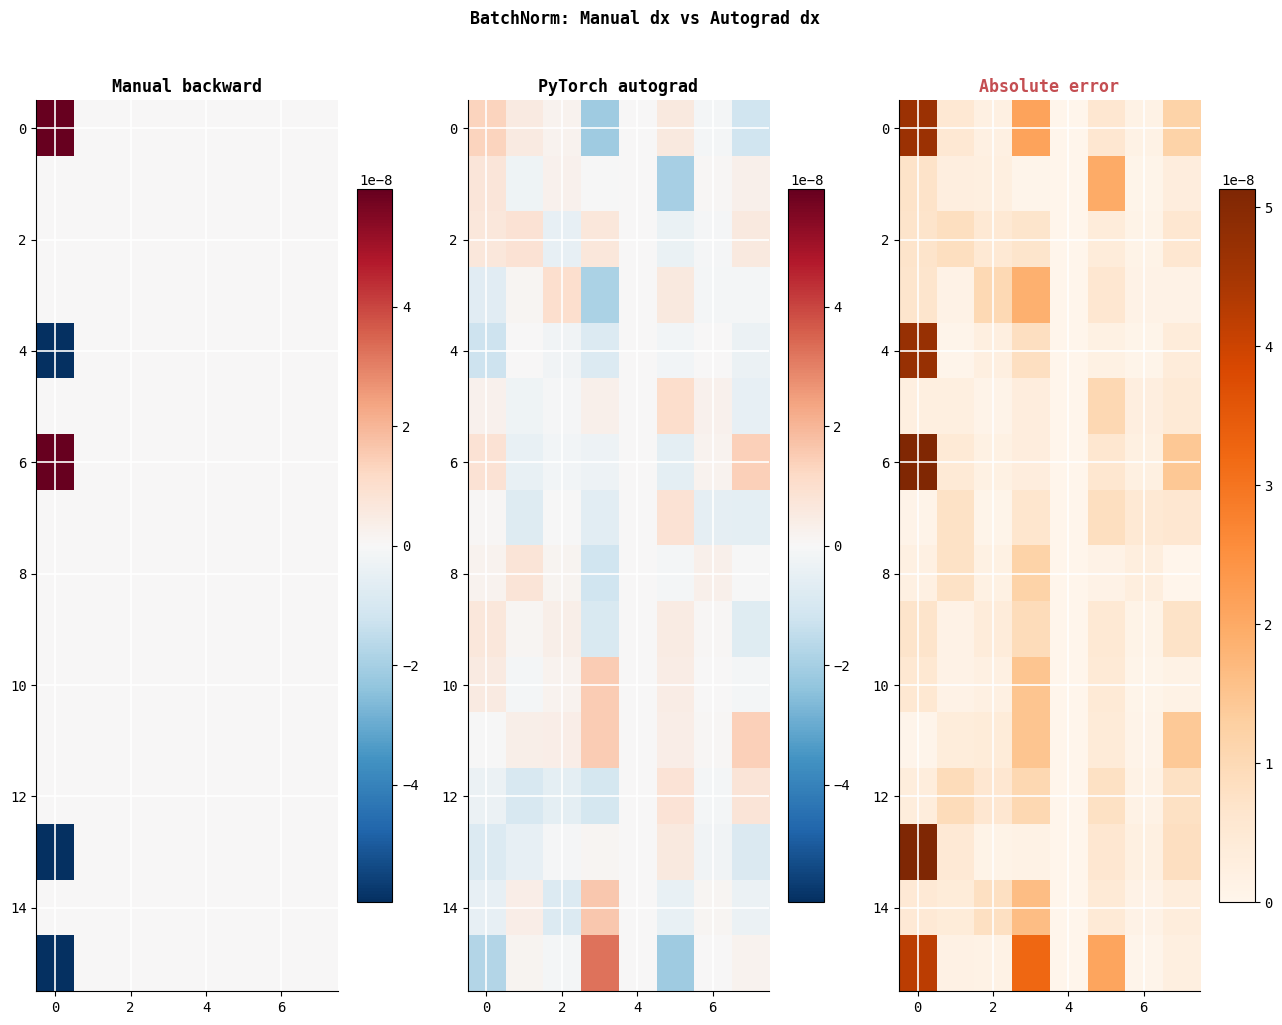

In [6]:
# Visual comparison of dx
x_auto = x.clone().detach().requires_grad_(True)
torch_bn = nn.BatchNorm1d(D, eps=bn.eps, momentum=bn.momentum)
torch_bn.weight.data = bn.gamma.clone()
torch_bn.bias.data   = bn.beta.clone()
torch_bn.train()
out_auto = torch_bn(x_auto)
out_auto.sum().backward()

fig = plot_gradient_check(dx, x_auto.grad, title="BatchNorm: Manual dx vs Autograd dx")
plt.show()


## 4. Running Stats and Inference Mode

During training, we compute batch statistics. At inference time (`.eval()`),
we need statistics that don't depend on the current batch — so we maintain
exponential moving averages (EMA) of mean and variance.

$$\text{running\_mean} \leftarrow (1 - m) \cdot \text{running\_mean} + m \cdot \mu_{\text{batch}}$$
$$\text{running\_var}  \leftarrow (1 - m) \cdot \text{running\_var}  + m \cdot \sigma^2_{\text{batch}}$$

This is why BatchNorm **fails with batch size = 1**: the variance would be 0, and
we'd be dividing by $\sqrt{\epsilon}$ which is essentially meaningless.


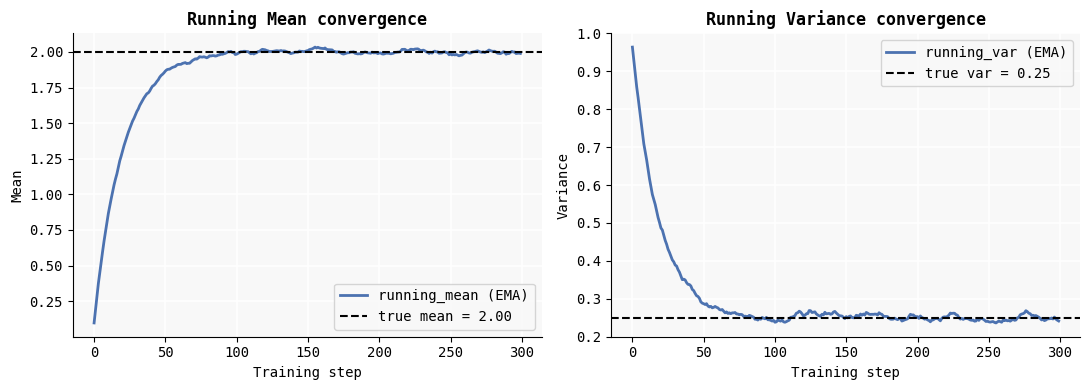

After 300 steps:
  running_mean[0] = 1.9891  (true: 2.0000)
  running_var[0]  = 0.2412   (true: 0.2500)


In [7]:
# Demonstrate running stats convergence
torch.manual_seed(42)
true_mean = torch.tensor([2.0, -1.5, 0.5, 3.0])
true_std  = torch.tensor([0.5,  2.0, 1.0, 0.3])
D_demo    = 4

bn_demo = BatchNorm1dManual(num_features=D_demo, momentum=0.05)
running_means, running_vars = [], []

n_steps = 300
for step in range(n_steps):
    x_batch = torch.randn(32, D_demo) * true_std + true_mean
    _ = bn_demo.forward(x_batch)
    running_means.append(bn_demo.running_mean.clone().numpy())
    running_vars.append(bn_demo.running_var.clone().numpy())

fig = plot_running_stats(
    np.array(running_means), np.array(running_vars),
    true_mean.numpy(), (true_std**2).numpy(),
    feature_idx=0
)
plt.show()
print("After 300 steps:")
print(f"  running_mean[0] = {bn_demo.running_mean[0]:.4f}  (true: {true_mean[0]:.4f})")
print(f"  running_var[0]  = {bn_demo.running_var[0]:.4f}   (true: {true_std[0]**2:.4f})")


## 5. Does BatchNorm Actually Help? Training Experiment

Let's train a 4-layer MLP on a synthetic dataset with and without BatchNorm
and compare:
1. Training loss convergence
2. Activation distributions across layers (does covariate shift reduce?)
3. Gradient magnitudes (does BatchNorm help with vanishing/exploding gradients?)


In [8]:
# Build dataset with deliberate covariate shift (features at very different scales)
X, Y = make_dataset(n_samples=2000, n_features=16, n_classes=4,
                    covariate_shift=True, seed=0)

print(f"Dataset: X={X.shape}, Y={Y.shape}")
print(f"Feature scale range: {X.std(0).min():.2f} to {X.std(0).max():.2f}")


Dataset: X=torch.Size([2000, 16]), Y=torch.Size([2000])
Feature scale range: 0.10 to 99.19


In [9]:
norm_factories = {
    'batchnorm': lambda d: nn.BatchNorm1d(d),
    'nonorm':    None,
}

histories = compare_norms(
    norm_factories, X, Y,
    hidden_dim=64, n_layers=4,
    lr=0.05, n_steps=1500, batch_size=64
)



  Training with: batchnorm
step     0 | loss 1.3753
step   100 | loss 0.3917
step   200 | loss 0.1071
step   300 | loss 0.3933
step   400 | loss 0.3309
step   500 | loss 0.2164
step   600 | loss 0.2756
step   700 | loss 0.2829
step   800 | loss 0.2991
step   900 | loss 0.5812
step  1000 | loss 0.2034
step  1100 | loss 0.3539
step  1200 | loss 0.1874
step  1300 | loss 0.1492
step  1400 | loss 0.1440

  Training with: nonorm
step     0 | loss 1.3423
step   100 | loss 0.2314
step   200 | loss 0.1686
step   300 | loss 0.1589
step   400 | loss 0.1101
step   500 | loss 0.0775
step   600 | loss 0.1588
step   700 | loss 0.1683
step   800 | loss 0.1263
step   900 | loss 0.0898
step  1000 | loss 0.0965
step  1100 | loss 0.0994
step  1200 | loss 0.0782
step  1300 | loss 0.0763
step  1400 | loss 0.0787


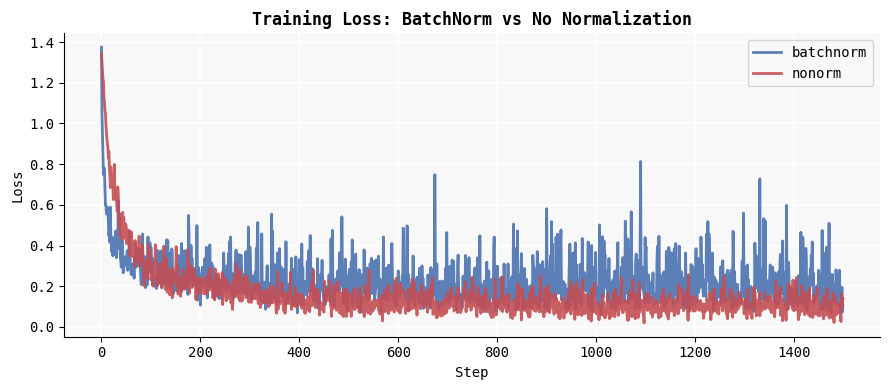

In [10]:
fig = plot_training_curves(
    {k: v['losses'] for k, v in histories.items()},
    title="Training Loss: BatchNorm vs No Normalization"
)
plt.show()


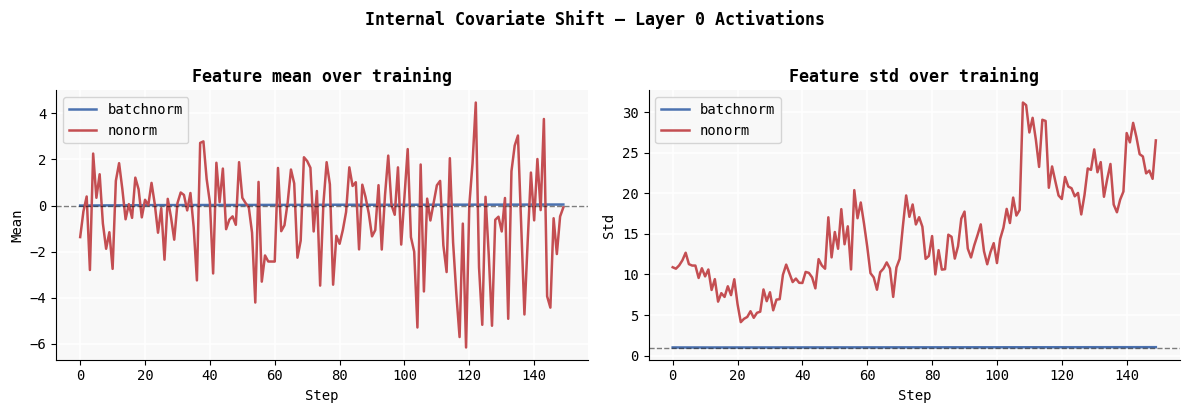

In [11]:
# Covariate shift: how does the activation distribution of layer 0 evolve?
fig = plot_covariate_shift(
    {k: v['act_means'] for k, v in histories.items()},
    {k: v['act_stds']  for k, v in histories.items()},
    feature_idx=0,
    title="Internal Covariate Shift — Layer 0 Activations"
)
plt.show()


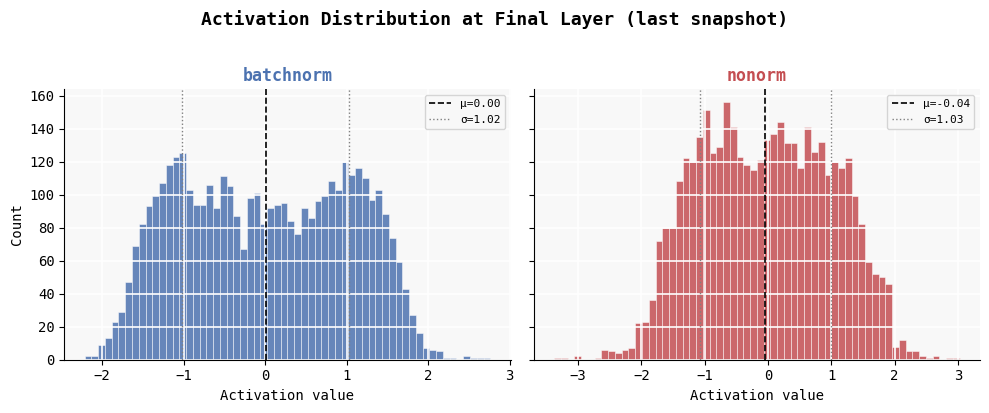

In [12]:
# Activation distributions at the last layer snapshot
fig = plot_activation_distributions(
    {k: v['activations'][-1] for k, v in histories.items()},
    layer_idx=-1,
    title="Activation Distribution at Final Layer (last snapshot)"
)
plt.show()


## 6. The Small-Batch Problem

BatchNorm estimates statistics from the mini-batch. With small batches,
these estimates are noisy, making training unstable.

**Practical rule of thumb**: BatchNorm needs batch size ≥ 16 to be reliable.
For batch sizes < 8, switch to LayerNorm or GroupNorm.

Let's verify this empirically.


step     0 | loss 1.6071
step     0 | loss 1.3656
step     0 | loss 1.7233
step     0 | loss 1.8271
step     0 | loss 1.8349


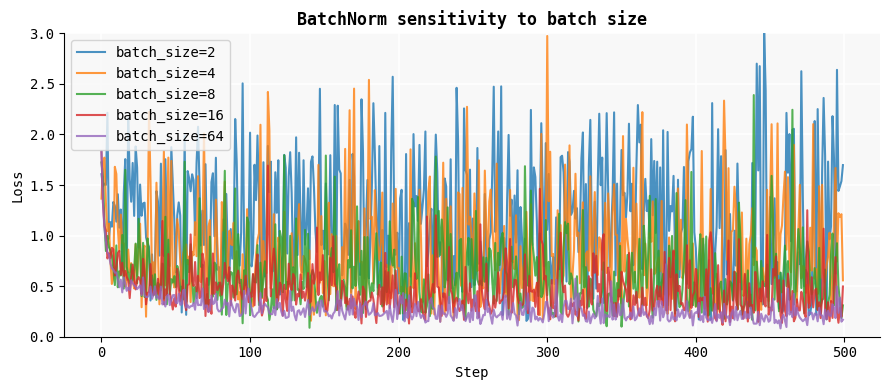


Final loss by batch size:
  batch_size=  2: 1.1687
  batch_size=  4: 0.9752
  batch_size=  8: 0.6324
  batch_size= 16: 0.3834
  batch_size= 64: 0.2220


In [13]:
batch_sizes = [2, 4, 8, 16, 64]
final_losses = {}

for bs in batch_sizes:
    torch.manual_seed(0)
    model = NormMLP(in_dim=16, hidden_dim=64, out_dim=4, n_layers=3,
                    norm_factory=lambda d: nn.BatchNorm1d(d))
    from train import train as run_train
    h = run_train(model, X, Y, lr=0.05, n_steps=500, batch_size=bs, log_every=500)
    final_losses[bs] = h['losses']

fig, ax = plt.subplots(figsize=(9, 4))
for bs, losses in final_losses.items():
    ax.plot(losses, label=f'batch_size={bs}', alpha=0.8)
ax.set_title("BatchNorm sensitivity to batch size", fontweight='bold')
ax.set_xlabel("Step"); ax.set_ylabel("Loss")
ax.legend(); ax.set_ylim(0, 3)
plt.tight_layout(); plt.show()
print("\nFinal loss by batch size:")
for bs, losses in final_losses.items():
    print(f"  batch_size={bs:3d}: {np.mean(losses[-50:]):.4f}")


## Summary

| Topic | Key Insight |
|---|---|
| Forward pass | Normalize over **N** (batch) per feature |
| Backward pass | Three paths: through $\hat{x}$, through $\sigma^2$, through $\mu$ |
| Running stats | EMA accumulation — needed because test-time has no batch |
| Small batch | Variance estimate is noisy; use LayerNorm below batch size ~16 |
| Affine params | $\gamma$, $\beta$ allow the network to undo normalization if needed |

**Next**: `02_layernorm_internals.ipynb` — how LayerNorm normalizes over features
instead of the batch, why that makes it perfect for transformers.
